# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Pengolahan Citra  
**Nama:** M. FARIQ FIRMANSYAH  
**NIM:** 122400086  

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


Gambar berhasil dibaca


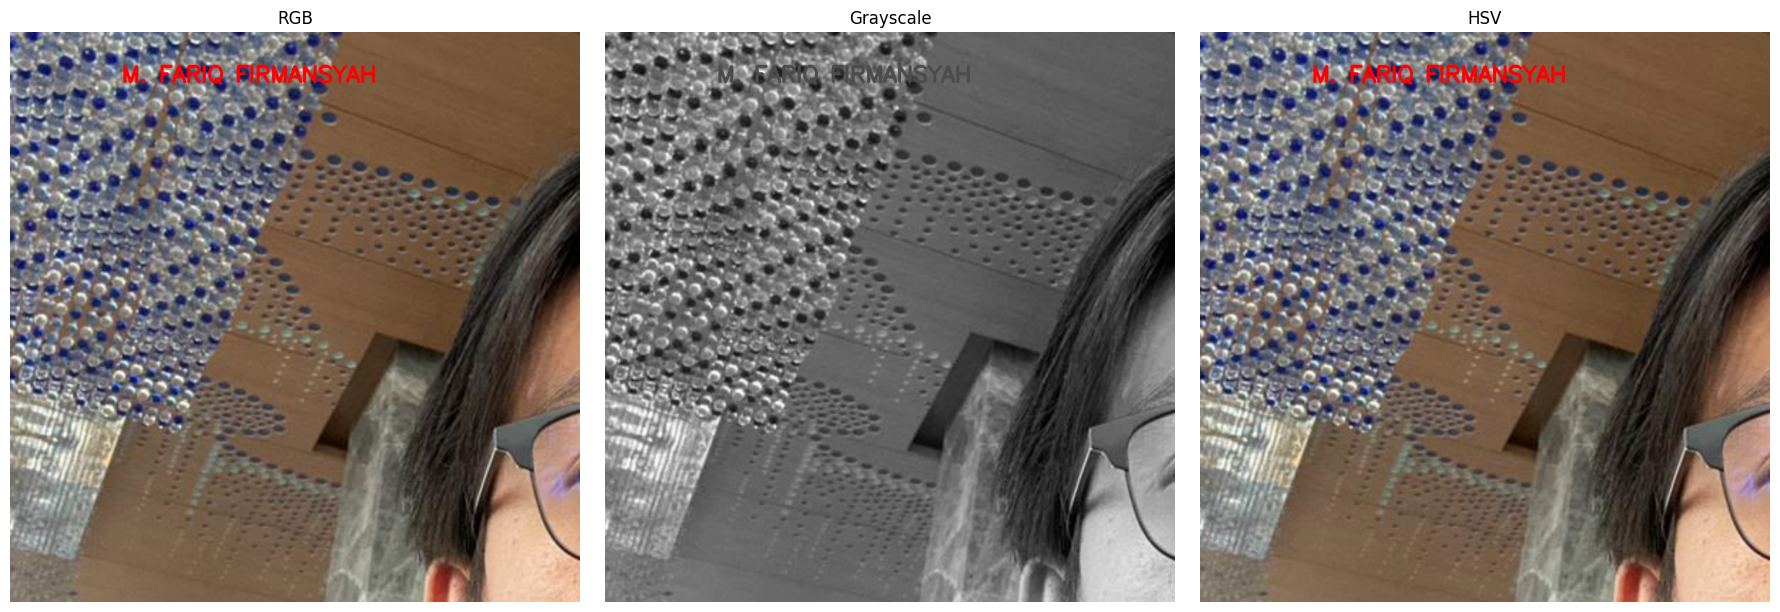

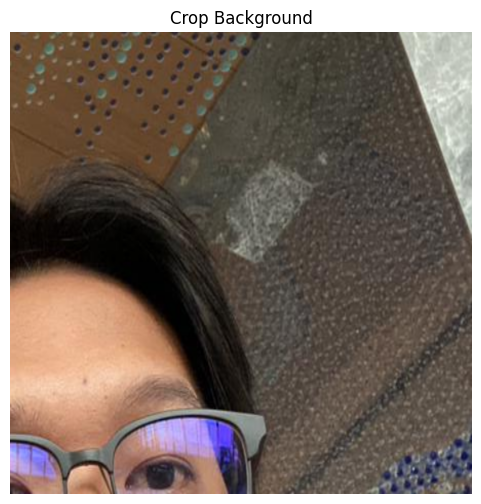

In [1]:
# ========================================
# IMPORT LIBRARY
# ========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# LOAD GAMBAR
# ========================================


img_path = os.path.join("assets_ws4", "selfie.jpeg")

img = cv2.imread(img_path)

# Cek apakah gambar berhasil dibaca
if img is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca")

# Convert BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ========================================
# CROPPING MANUAL
# ========================================

# Crop wajah (PERSEGI)
# Format: [y1:y2, x1:x2]

face_crop = img_rgb[100:500, 200:600]

# Crop background (PERSEGI PANJANG)

background_crop = img_rgb[50:400, 650:1100]

# ========================================
# RESIZE 920x920
# ========================================

face_resize = cv2.resize(face_crop, (920, 920))
background_resize = cv2.resize(background_crop, (920, 920))

# ========================================
# ANOTASI NAMA
# ========================================

img_annotated = face_resize.copy()

cv2.putText(
    img_annotated,
    "M. FARIQ FIRMANSYAH",
    (180, 80),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.2,
    (255, 0, 0),
    3
)

# ========================================
# KONVERSI WARNA
# ========================================

# Grayscale
img_gray = cv2.cvtColor(img_annotated, cv2.COLOR_RGB2GRAY)

# HSV
img_hsv = cv2.cvtColor(img_annotated, cv2.COLOR_RGB2HSV)

# HSV ke RGB agar bisa ditampilkan matplotlib
img_hsv_display = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

# ========================================
# VISUALISASI
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RGB
axes[0].imshow(img_annotated)
axes[0].set_title("RGB")
axes[0].axis("off")

# Grayscale
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[1].axis("off")

# HSV
axes[2].imshow(img_hsv_display)
axes[2].set_title("HSV")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ========================================
# TAMPILKAN HASIL CROP BACKGROUND
# ========================================

plt.figure(figsize=(6,6))

plt.imshow(background_resize)

plt.title("Crop Background")

plt.axis("off")

plt.show()

 Pada proses pengolahan citra menggunakan Python dan OpenCV. Gambar selfie dimuat dari folder lokal kemudian dikonversi dari format BGR ke RGB agar warna dapat ditampilkan dengan benar pada matplotlib. Selanjutnya dilakukan cropping manual pada area wajah berbentuk persegi dan area latar belakang berbentuk persegi panjang menggunakan teknik slicing array. Hasil cropping kemudian di-resize menjadi 920×920 piksel agar ukuran gambar seragam. Setelah itu ditambahkan anotasi teks berupa nama di atas kepala menggunakan fungsi `cv2.putText()` dengan pengaturan font, warna, dan ketebalan tertentu. Gambar hasil crop juga dikonversi ke grayscale untuk menampilkan intensitas cahaya tanpa warna, serta ke HSV untuk mempermudah analisis berdasarkan hue, saturation, dan value. Terakhir, seluruh hasil pengolahan ditampilkan berdampingan menggunakan matplotlib sehingga perbedaan antara RGB, grayscale, dan HSV dapat diamati dengan jelas.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


Gambar berhasil disimpan: hasil_modifikasi_rgb.png


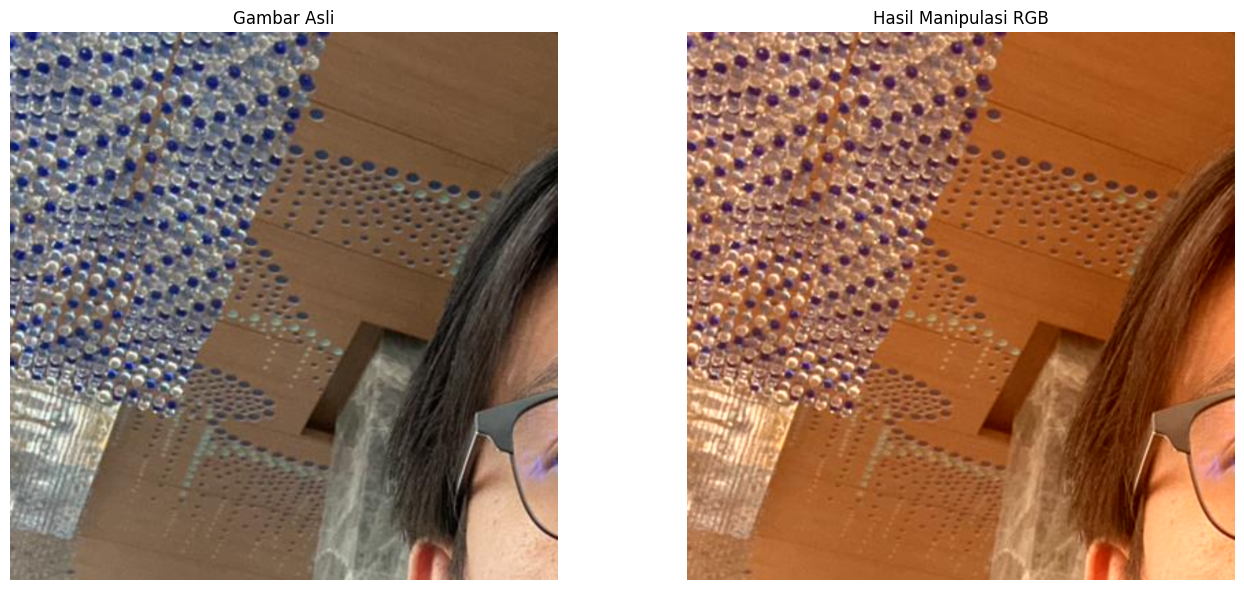

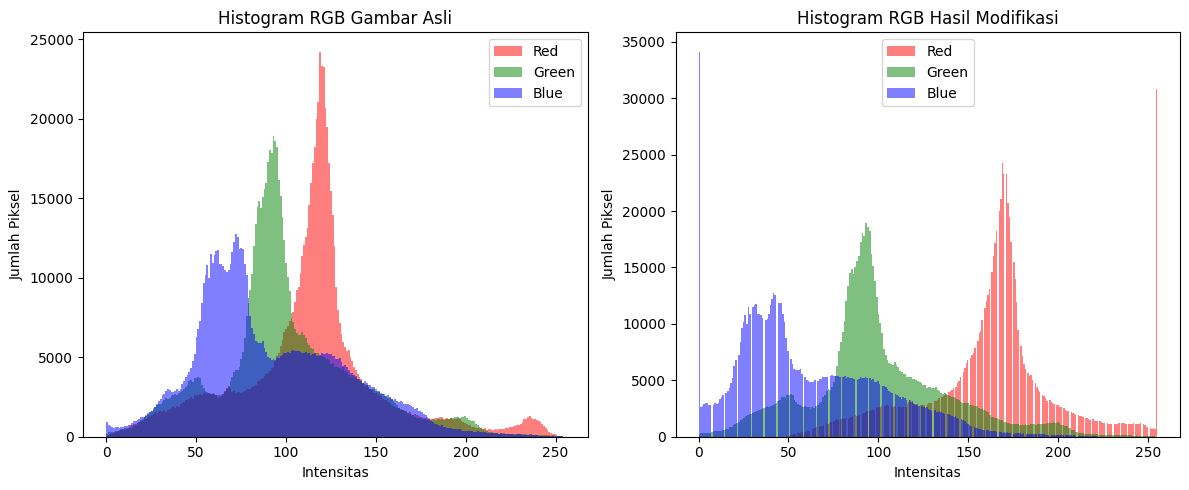

In [1]:
# ========================================
# IMPORT LIBRARY
# ========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# LOAD GAMBAR
# ========================================

img_path = os.path.join("assets_ws4", "selfie.jpeg")

img = cv2.imread(img_path)

# Convert BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ========================================
# CROP GAMBAR (HASIL SOAL 1)
# ========================================

img_crop = img_rgb[100:500, 200:600]

# Resize agar seragam
img_crop = cv2.resize(img_crop, (920, 920))

# ========================================
# SPLIT CHANNEL RGB
# ========================================

R = img_crop[:, :, 0].astype(np.int32)
G = img_crop[:, :, 1].astype(np.int32)
B = img_crop[:, :, 2].astype(np.int32)

# ========================================
# MANIPULASI CHANNEL
# ========================================

# Tambah merah +50
R_modified = np.clip(R + 50, 0, 255)

# Kurangi biru -30
B_modified = np.clip(B - 30, 0, 255)

# Channel hijau tetap
G_modified = G

# ========================================
# GABUNGKAN CHANNEL
# ========================================

img_modified = np.stack(
    [R_modified, G_modified, B_modified],
    axis=2
).astype(np.uint8)

# ========================================
# SIMPAN GAMBAR PNG
# ========================================

output_path = "hasil_modifikasi_rgb.png"

cv2.imwrite(
    output_path,
    cv2.cvtColor(img_modified, cv2.COLOR_RGB2BGR)
)

print(f"Gambar berhasil disimpan: {output_path}")

# ========================================
# VISUALISASI GAMBAR
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gambar asli
axes[0].imshow(img_crop)
axes[0].set_title("Gambar Asli")
axes[0].axis("off")

# Gambar hasil modifikasi
axes[1].imshow(img_modified)
axes[1].set_title("Hasil Manipulasi RGB")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ========================================
# HISTOGRAM RGB GAMBAR ASLI
# ========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(img_crop[:,:,0].ravel(), bins=256, color='red', alpha=0.5, label='Red')
plt.hist(img_crop[:,:,1].ravel(), bins=256, color='green', alpha=0.5, label='Green')
plt.hist(img_crop[:,:,2].ravel(), bins=256, color='blue', alpha=0.5, label='Blue')

plt.title("Histogram RGB Gambar Asli")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.legend()

# ========================================
# HISTOGRAM RGB HASIL MODIFIKASI
# ========================================

plt.subplot(1,2,2)

plt.hist(img_modified[:,:,0].ravel(), bins=256, color='red', alpha=0.5, label='Red')
plt.hist(img_modified[:,:,1].ravel(), bins=256, color='green', alpha=0.5, label='Green')
plt.hist(img_modified[:,:,2].ravel(), bins=256, color='blue', alpha=0.5, label='Blue')

plt.title("Histogram RGB Hasil Modifikasi")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.legend()

plt.tight_layout()
plt.show()

Dilakukan manipulasi channel warna RGB pada gambar hasil cropping untuk memahami pengaruh perubahan intensitas warna terhadap tampilan citra. Gambar terlebih dahulu dikonversi ke ruang warna RGB, kemudian dipisahkan menjadi tiga channel utama yaitu Red (R), Green (G), dan Blue (B). Proses manipulasi dilakukan dengan menaikkan intensitas channel merah sebesar 50 poin sehingga warna merah pada gambar menjadi lebih dominan dan memberikan efek visual yang lebih hangat. Selain itu, intensitas channel biru diturunkan sebesar 30 poin untuk mengurangi nuansa dingin pada gambar. Agar nilai piksel tetap valid dan tidak melebihi batas rentang warna digital, digunakan fungsi `np.clip()` sehingga seluruh nilai tetap berada pada rentang 0–255. 

Setelah proses manipulasi selesai, ketiga channel digabungkan kembali menjadi citra RGB baru dan disimpan dalam format `.png`. Perubahan yang dihasilkan terlihat cukup jelas, di mana warna kulit dan objek pada gambar tampak lebih kemerahan, lebih terang, dan memiliki tone warna yang lebih hangat dibandingkan gambar asli. Pengurangan channel biru juga membuat warna biru pada gambar menjadi lebih redup sehingga keseimbangan warna bergeser ke arah merah dan kuning.

Histogram RGB digunakan untuk menganalisis distribusi intensitas warna sebelum dan sesudah manipulasi. Pada histogram hasil modifikasi terlihat bahwa distribusi channel merah bergeser ke arah kanan yang menandakan peningkatan intensitas merah, sedangkan distribusi channel biru bergeser ke arah kiri akibat pengurangan intensitas biru. Sementara itu, channel hijau relatif tidak berubah karena tidak dilakukan manipulasi pada channel tersebut. Dari hasil ini dapat disimpulkan bahwa perubahan intensitas pada masing-masing channel RGB sangat memengaruhi karakter warna dan suasana visual pada sebuah citra digital.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


Gambar berhasil dibaca


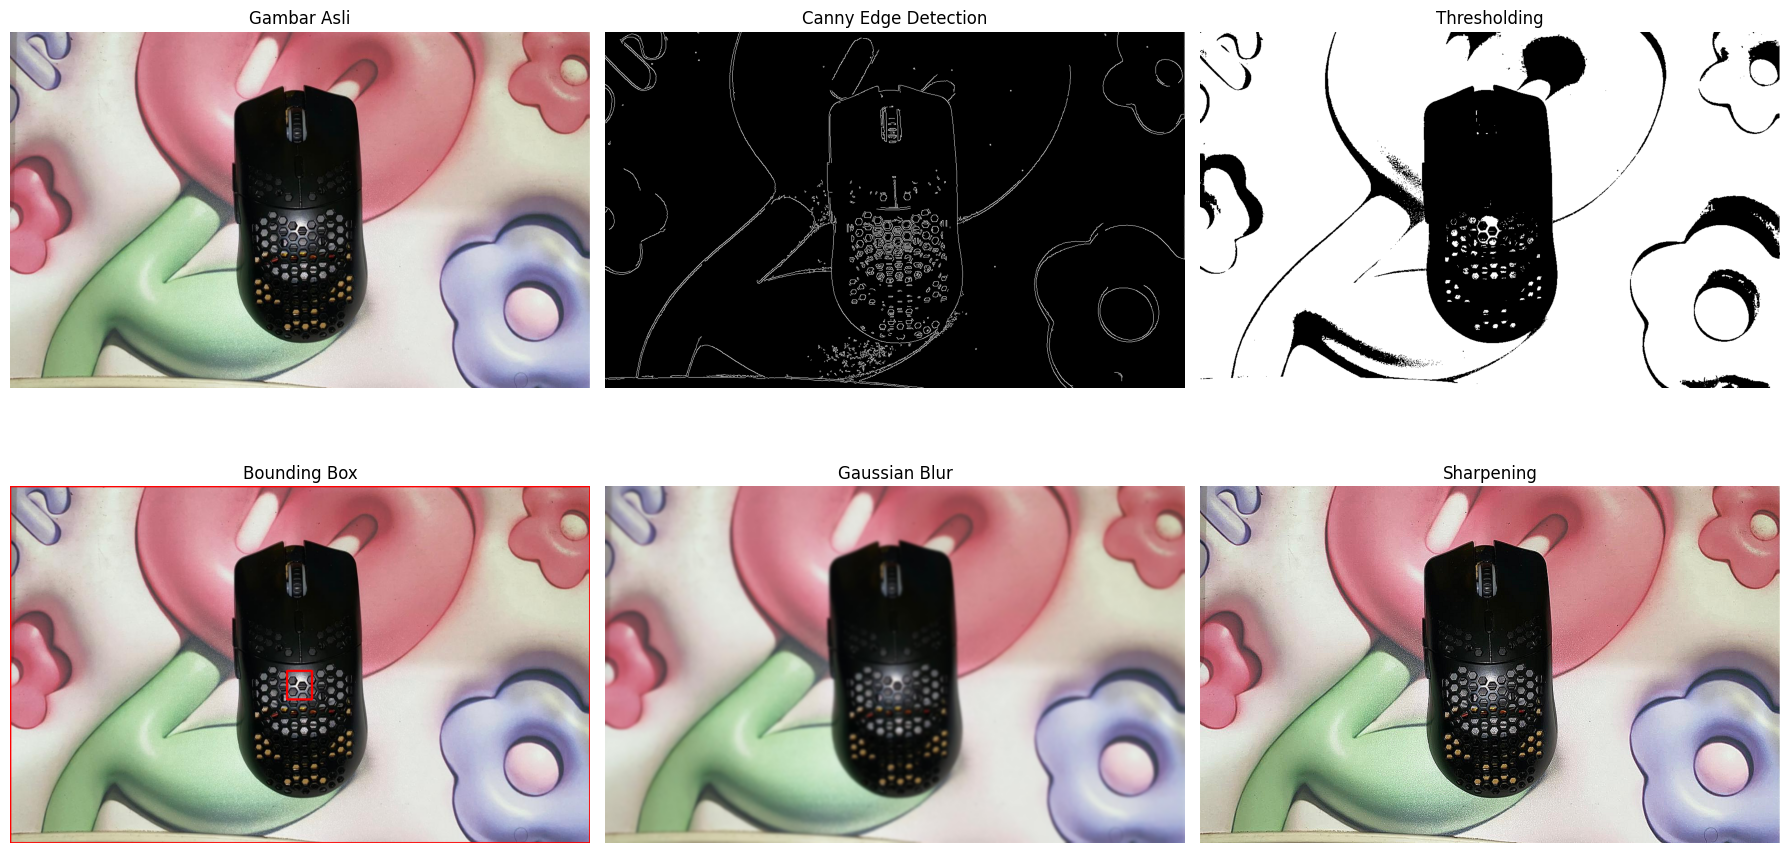

In [2]:
# ========================================
# IMPORT LIBRARY
# ========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# LOAD GAMBAR
# ========================================

img_path = os.path.join("assets_ws4", "pattern.jpeg")

img = cv2.imread(img_path)

# Cek gambar
if img is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca")

# Convert BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ========================================
# EDGE DETECTION (CANNY)
# ========================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(
    gray,
    threshold1=100,
    threshold2=200
)

# ========================================
# THRESHOLDING
# ========================================

_, thresh = cv2.threshold(
    gray,
    120,          # nilai threshold
    255,
    cv2.THRESH_BINARY
)

# ========================================
# CONTOUR & BOUNDING BOX
# ========================================

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_bbox = img_rgb.copy()

for contour in contours:

    area = cv2.contourArea(contour)

    # Filter contour kecil
    if area > 1000:

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            img_bbox,
            (x, y),
            (x+w, y+h),
            (255, 0, 0),
            3
        )

# ========================================
# FILTER BLUR
# ========================================

img_blur = cv2.GaussianBlur(
    img_rgb,
    (15,15),
    0
)

# ========================================
# FILTER SHARPENING
# ========================================

kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

img_sharp = cv2.filter2D(
    img_rgb,
    -1,
    kernel_sharpen
)

# ========================================
# VISUALISASI
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gambar asli
axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Gambar Asli")
axes[0,0].axis("off")

# Edge detection
axes[0,1].imshow(edges, cmap='gray')
axes[0,1].set_title("Canny Edge Detection")
axes[0,1].axis("off")

# Threshold
axes[0,2].imshow(thresh, cmap='gray')
axes[0,2].set_title("Thresholding")
axes[0,2].axis("off")

# Bounding box
axes[1,0].imshow(img_bbox)
axes[1,0].set_title("Bounding Box")
axes[1,0].axis("off")

# Blur
axes[1,1].imshow(img_blur)
axes[1,1].set_title("Gaussian Blur")
axes[1,1].axis("off")

# Sharpen
axes[1,2].imshow(img_sharp)
axes[1,2].set_title("Sharpening")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

Gambar objek dengan background bertekstur terlebih dahulu dikonversi ke grayscale untuk mempermudah proses analisis citra. Selanjutnya diterapkan metode Canny Edge Detection untuk mendeteksi tepi objek berdasarkan perubahan intensitas piksel. Hasil edge detection menunjukkan garis-garis tepi objek yang cukup jelas sehingga bentuk objek dapat dikenali meskipun background memiliki tekstur yang kompleks.

Setelah itu dilakukan thresholding dengan nilai ambang tertentu untuk memisahkan objek utama dari background. Proses thresholding mengubah citra menjadi biner sehingga area objek dan background dapat dibedakan dengan lebih mudah. Dari hasil segmentasi tersebut dilakukan pencarian contour dan pembuatan bounding box menggunakan `cv2.rectangle()` untuk menandai lokasi objek utama pada gambar.

Selain deteksi tepi, dilakukan juga penerapan filter blur dan sharpening untuk membandingkan pengaruhnya terhadap detail gambar. Filter Gaussian Blur digunakan untuk menghaluskan citra dengan cara mengurangi noise dan detail kecil sehingga gambar terlihat lebih lembut namun kehilangan sebagian detail tepi. Sebaliknya, filter sharpening digunakan untuk mempertegas detail dan meningkatkan ketajaman tepi objek sehingga tekstur dan garis pada gambar terlihat lebih jelas. Dari hasil perbandingan dapat disimpulkan bahwa blur cocok digunakan untuk reduksi noise, sedangkan sharpening lebih cocok digunakan untuk memperjelas detail pada citra digital.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

Gambar berhasil dibaca


c:\Users\fariq\AppData\Local\Programs\Python\Python310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


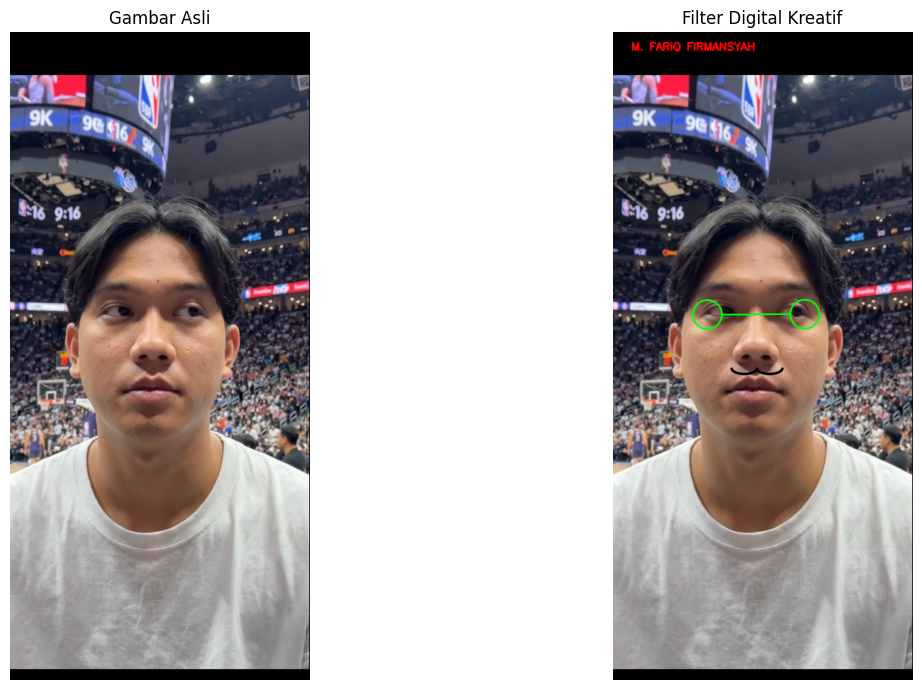

In [4]:
# ========================================
# IMPORT LIBRARY
# ========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
import os

# ========================================
# LOAD GAMBAR
# ========================================

img_path = os.path.join("assets_ws4", "flat1.jpeg")

img = cv2.imread(img_path)

if img is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca")

# Convert BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ========================================
# INISIALISASI MEDIAPIPE FACE MESH
# ========================================

mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    min_detection_confidence=0.5
)

# ========================================
# DETEKSI LANDMARK WAJAH
# ========================================

results = face_mesh.process(img_rgb)

# Copy gambar untuk hasil akhir
img_filter = img_rgb.copy()

# ========================================
# FILTER DIGITAL KREATIF
# CONTOH: KACAMATA + KUMIS
# ========================================

if results.multi_face_landmarks:

    for face_landmarks in results.multi_face_landmarks:

        h, w, _ = img_rgb.shape

        # ========================================
        # AMBIL TITIK MATA
        # ========================================

        left_eye = face_landmarks.landmark[33]
        right_eye = face_landmarks.landmark[263]

        left_eye_x = int(left_eye.x * w)
        left_eye_y = int(left_eye.y * h)

        right_eye_x = int(right_eye.x * w)
        right_eye_y = int(right_eye.y * h)

        # ========================================
        # GAMBAR KACAMATA
        # ========================================

        radius = 40

        # Lingkaran mata kiri
        cv2.circle(
            img_filter,
            (left_eye_x, left_eye_y),
            radius,
            (0, 255, 0),
            4
        )

        # Lingkaran mata kanan
        cv2.circle(
            img_filter,
            (right_eye_x, right_eye_y),
            radius,
            (0, 255, 0),
            4
        )

        # Garis penghubung
        cv2.line(
            img_filter,
            (left_eye_x + radius, left_eye_y),
            (right_eye_x - radius, right_eye_y),
            (0, 255, 0),
            4
        )

        # ========================================
        # AMBIL TITIK HIDUNG
        # ========================================

        nose = face_landmarks.landmark[1]

        nose_x = int(nose.x * w)
        nose_y = int(nose.y * h)

        # ========================================
        # GAMBAR KUMIS
        # ========================================

        cv2.ellipse(
            img_filter,
            (nose_x - 35, nose_y + 40),
            (35, 15),
            0,
            0,
            180,
            (0, 0, 0),
            6
        )

        cv2.ellipse(
            img_filter,
            (nose_x + 35, nose_y + 40),
            (35, 15),
            0,
            0,
            180,
            (0, 0, 0),
            6
        )

        # ========================================
        # TAMBAHKAN NAMA
        # ========================================

        cv2.putText(
            img_filter,
            "M. FARIQ FIRMANSYAH",
            (50, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            3
        )

# ========================================
# VISUALISASI
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Gambar asli
axes[0].imshow(img_rgb)
axes[0].set_title("Gambar Asli")
axes[0].axis("off")

# Gambar dengan filter
axes[1].imshow(img_filter)
axes[1].set_title("Filter Digital Kreatif")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Untuk mendeteksi wajah, saya menggunakan MediaPipe Face Mesh yang mampu mengambil landmark wajah secara otomatis. Landmark yang digunakan meliputi tiga titik utama, yaitu mata kiri, mata kanan, dan hidung. Dari koordinat ketiga titik tersebut, posisi filter digital dapat dihitung sehingga aksesoris yang ditampilkan bisa menyesuaikan bentuk wajah dengan lebih natural.
Filter yang dibuat terdiri dari dua jenis, yaitu kacamata dan kumis. Kacamata dibuat menggunakan kombinasi lingkaran dan garis yang ditempatkan tepat di area kedua mata, mengacu pada landmark mata kiri dan kanan. Sementara itu, kumis dibuat menggunakan bentuk ellipse yang diposisikan di bawah hidung berdasarkan koordinat landmark hidung. Pendekatan ini memungkinkan posisi filter tetap sesuai meskipun ukuran wajah pada gambar berbeda-beda.
Hasil yang diperoleh cukup memuaskan, di mana filter berhasil mengikuti struktur wajah dengan baik dan tampak lebih realistis. Namun, terdapat beberapa tantangan yang saya temui selama proses implementasi. Tantangan terbesar adalah menentukan ukuran overlay yang proporsional terhadap wajah serta menyesuaikan posisi filter agar tidak bergeser dari area landmark. Di samping itu, faktor pencahayaan dan kualitas gambar juga terbukti berpengaruh terhadap akurasi deteksi landmark pada MediaPipe semakin rendah kualitas gambar, semakin berkurang pula ketelitian deteksinya.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

Gambar berhasil dibaca


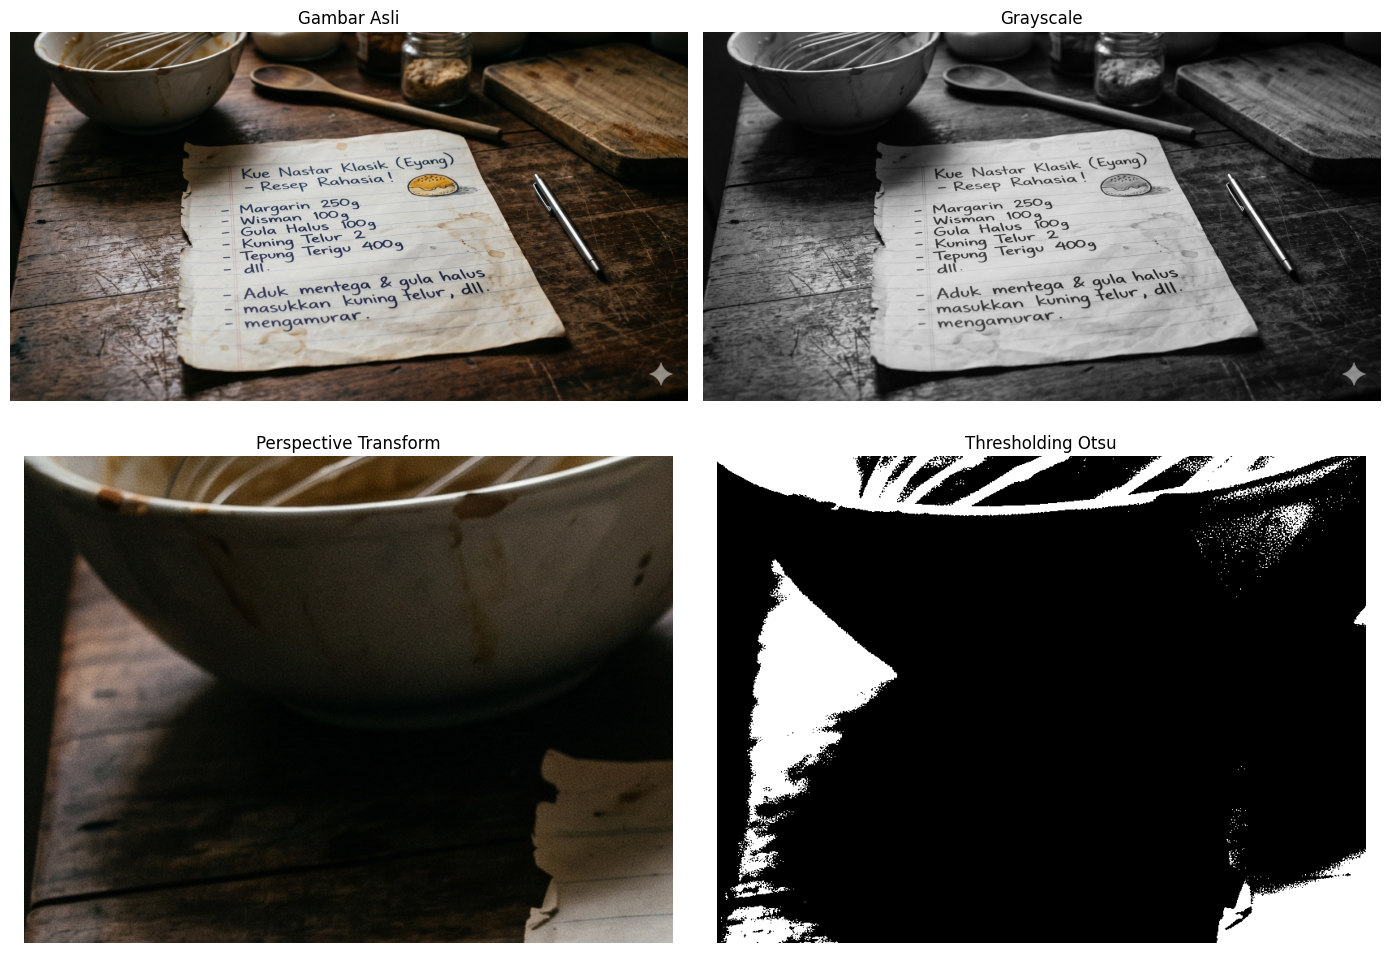

In [5]:
# ========================================
# IMPORT LIBRARY
# ========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# LOAD GAMBAR
# ========================================

img_path = os.path.join("assets_ws4", "unideal.png")

img = cv2.imread(img_path)

if img is None:
    print("Gambar tidak ditemukan!")
else:
    print("Gambar berhasil dibaca")

# Convert BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ========================================
# KONVERSI GRAYSCALE
# ========================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ========================================
# PERSPEKTIF TRANSFORM (HOMOGRAFI)
# ========================================

# Titik sumber (manual)
# Format: [x, y]

pts_src = np.float32([
    [120, 100],   # kiri atas
    [850, 120],   # kanan atas
    [80, 700],    # kiri bawah
    [900, 720]    # kanan bawah
])

# Titik tujuan
width = 800
height = 600

pts_dst = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])

# Matriks homografi
matrix = cv2.getPerspectiveTransform(
    pts_src,
    pts_dst
)

# Warp perspective
img_warp = cv2.warpPerspective(
    img_rgb,
    matrix,
    (width, height)
)

# ========================================
# KONVERSI GRAYSCALE HASIL WARP
# ========================================

warp_gray = cv2.cvtColor(
    img_warp,
    cv2.COLOR_RGB2GRAY
)

# ========================================
# THRESHOLDING OTSU
# ========================================

_, otsu = cv2.threshold(
    warp_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# ========================================
# VISUALISASI GRID
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gambar asli
axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Gambar Asli")
axes[0,0].axis("off")

# Grayscale
axes[0,1].imshow(gray, cmap='gray')
axes[0,1].set_title("Grayscale")
axes[0,1].axis("off")

# Perspective transform
axes[1,0].imshow(img_warp)
axes[1,0].set_title("Perspective Transform")
axes[1,0].axis("off")

# Threshold Otsu
axes[1,1].imshow(otsu, cmap='gray')
axes[1,1].set_title("Thresholding Otsu")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

Dilakukan proses peningkatan kualitas citra pada objek datar melalui beberapa tahapan preprocessing agar gambar terlihat lebih rapi dan mudah dianalisis. Gambar awal diambil dari sudut yang kurang ideal sehingga objek tampak miring dan mengalami distorsi perspektif. Untuk mengatasi hal tersebut, langkah pertama yang dilakukan adalah mengubah gambar menjadi grayscale. Konversi ini bertujuan menyederhanakan informasi warna menjadi tingkat intensitas cahaya sehingga proses pengolahan citra menjadi lebih efisien dan fokus pada detail utama objek.

Tahap berikutnya adalah melakukan koreksi perspektif menggunakan transformasi homografi dengan menentukan empat titik manual pada sudut objek. Proses ini memungkinkan citra dipetakan ulang sehingga posisi objek menjadi lebih lurus, sejajar, dan proporsional. Setelah perspektif diperbaiki, detail pada objek terlihat lebih jelas dan lebih nyaman untuk diamati.

Selanjutnya diterapkan thresholding menggunakan metode Otsu. Metode ini dipilih karena mampu menentukan nilai ambang secara otomatis berdasarkan distribusi intensitas piksel pada citra grayscale. Hasil thresholding membuat objek utama lebih terpisah dari background sehingga detail seperti tulisan atau bentuk objek menjadi lebih kontras dan mudah dibaca.

Secara keseluruhan, kombinasi grayscale, koreksi perspektif, dan thresholding berhasil meningkatkan kualitas visual citra. Gambar akhir terlihat lebih jelas, lebih rapi, memiliki kontras yang lebih baik, serta lebih mudah digunakan untuk proses analisis maupun dokumentasi digital.


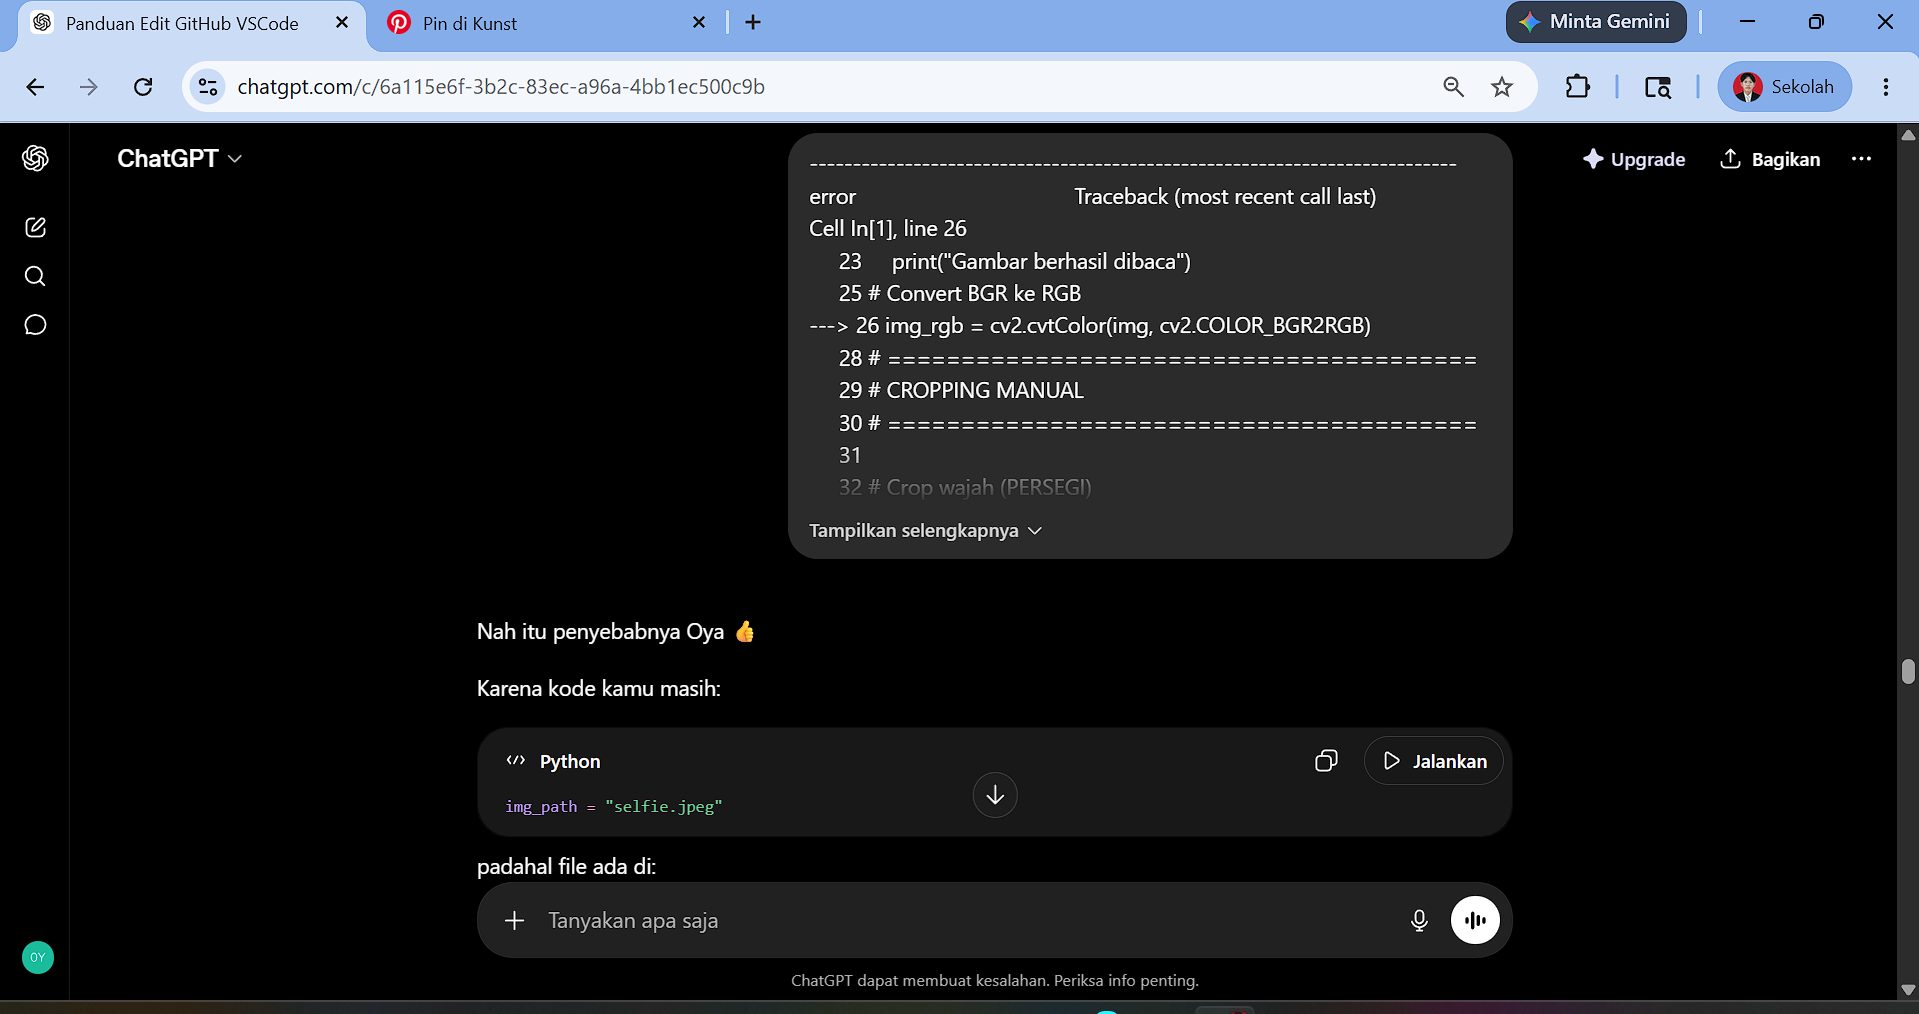 Bantuan AI dari Chatgpt

Referensi pengerjaan:

https://github.com/cvzone/cvzone

https://arxiv.org/pdf/1708.02694

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.